# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
#print(california['DESCR'])  # descripción del dataset
california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [6]:
from sklearn.model_selection import train_test_split
X, y = california['data'], california['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [7]:
y.shape

(20640,)

In [8]:
y_test.shape

(4128,)

### Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

# RESPUESTAS

1. El California Housing Dataset es un conjunto de datos reales extraído del censo de Estados Unidos de 1990. Cada fila representa un grupo de censado (census block group), que es la unidad geográfica más pequeña para la que se publicaron datos agregados. El conjunto busca relacionar características demográficas y socioeconómicas de cada distrito con el valor medio de las viviendas.

2. La variable objetivo a predecir es `MedHouseVal` que corresponde a la mediana del valor de las casas en los distritos de California, expresados en cientos de miles de dolares ($100,000).

3. Los atributos disponibles para hacer la predicción son:
  - `MedInc`: La mediana del ingreso del grupo de censado.
  - `HouseAge`: La mediana de la antiguedad de las casas en el grupo de censado.
  - `AveRooms`: El promedio del número de habitaciones por grupo familiar (household).
  - `AveBedrms`: El promedio del número de dormitorios por grupo familiar.
  - `Population`: Población del grupo de censado.
  - `AveOccup`: Número promedio de miembros del grupo familiar.
  - `Latitude`: Latitud del grupo de censado.
  - `Longitude`: Longitud del grupo de censado.

4. Nosotros pensamos que sin duda el atributo `MedInc` es importante debido a que la gente con mayores ingresos tiende a poder obtener casas más caras. Como la ubicación también importa en el precio de las casas, tanto `Latitude` como `Longitude` son determinantes. Por último, la antiguedad de las casas (`HouseAge`) puede ser otro factor a tener en cuenta.

5. Al ser un censo, creemos que el dataset debería ser una muestra contundente de la realidad, sin embargo, es importante notar que como todo conjunto de datos, pueden existir outliers o datos extraños. Además notemos que algunos atributos son promedios, por lo que pueden no contener toda la información sobre distribuciones irregulares.

## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

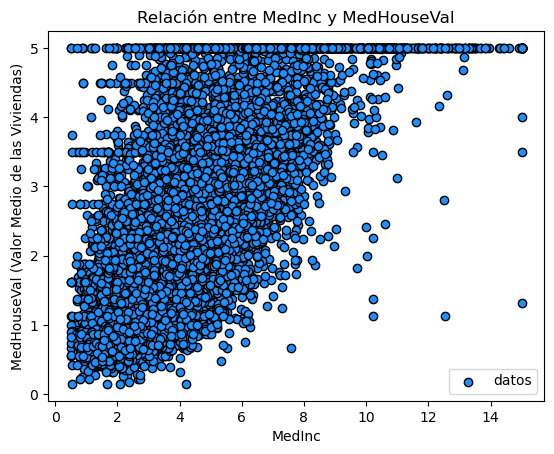

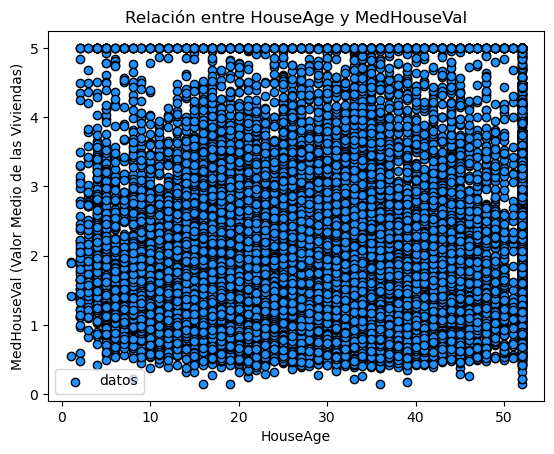

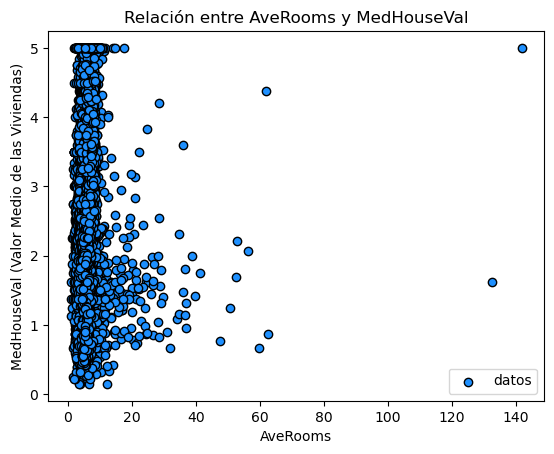

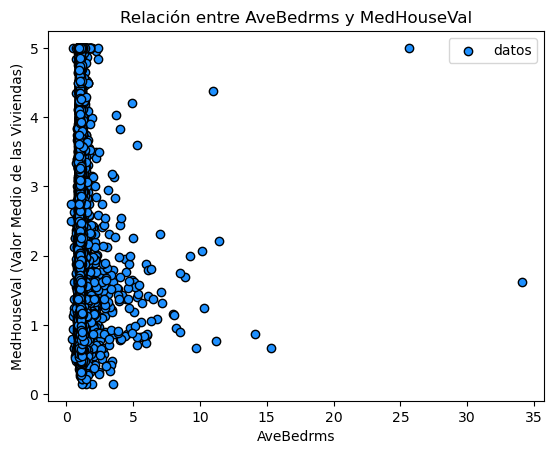

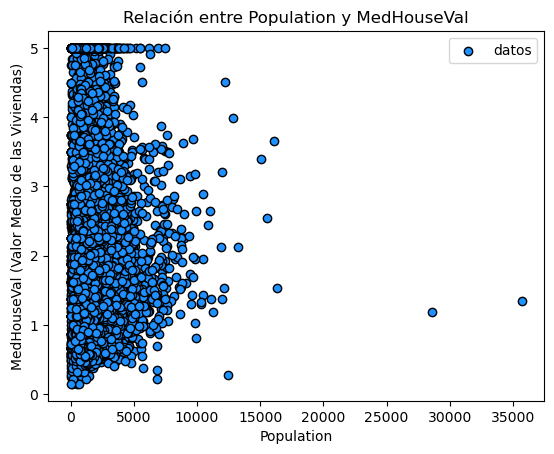

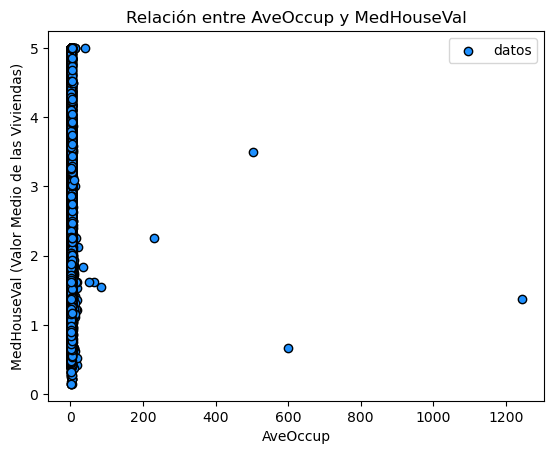

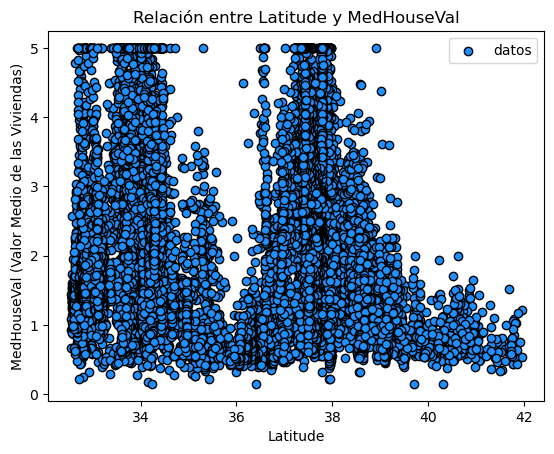

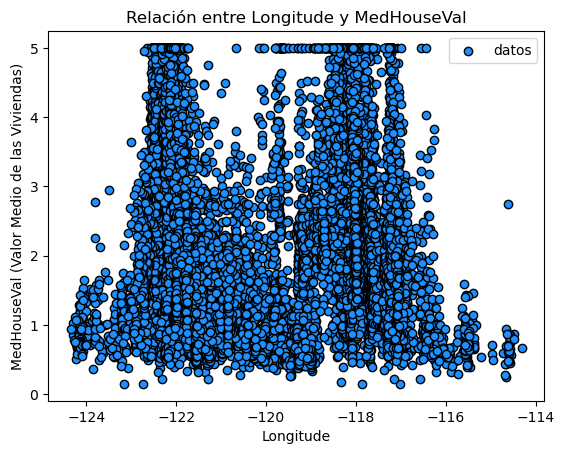

In [9]:
## Ejercicio 2: Visualización de los Datos (Automatizado)

# Obtener la lista de nombres de atributos
feature_names = california['feature_names']

# Iterar sobre cada nombre de atributo
for feature in feature_names:
    # Crear el selector booleano para el atributo actual
    selector = (np.array(feature_names) == feature)

    # Seleccionar los datos para el atributo actual
    X_feature = X[:, selector]

    # Crear el gráfico de dispersión
    plt.figure() # Crea una nueva figura para cada gráfico
    plt.scatter(X_feature, y, facecolor="dodgerblue", edgecolor="k", label="datos")

    # Configurar el título y las etiquetas de los ejes
    plt.title(f'Relación entre {feature} y MedHouseVal')
    plt.xlabel(feature)
    plt.ylabel('MedHouseVal (Valor Medio de las Viviendas)')
    plt.legend()

    # Mostrar el gráfico
    plt.show()

In [10]:
california['feature_names'][1] == feature

False

Tras observar los gráficos, destacamos los siguientes patrones:

- `MedInc`: Es el atributo que muestra una relación más clara con MedHouseVal. A medida que aumenta el ingreso medio, el valor medio de las viviendas también tiende a aumentar, con una relación con tendencia lineal.

- `AveRooms`, `AveBedrms` y `Population`: Estas variables presentan alta concentración de puntos en valores bajos, con algunos outliers extremos que generan cierta dispersión.

- `HouseAg`: Se observa una gran dispersión, aunque con algunos patrones verticales.

- `Latitude` y `Longitude`: Aunque no muestran una relación lineal con el precio, se nota una clara estructura espacial, con zonas específicas que concentran viviendas de mayor o menor valor. Esto sugiere que la ubicación geográfica tiene un rol importante en la determinación del precio.


Por lo tanto, proponemos el siguiente orden de atributos en función de su posible relevancia para la predicción:

1. `MedInc`
2. `Latitude` / `Longitude`
3. `HouseAge`
4. `AveRooms` / `AveBedrms` / `Population`

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

Forma de X_train_medinc: (16512, 1)
Forma de X_test_medinc: (4128, 1)
Error Cuadrático Medio (MSE) en Entrenamiento: 0.6960681099171515
Error Cuadrático Medio (MSE) en Evaluación: 0.7214982234014606


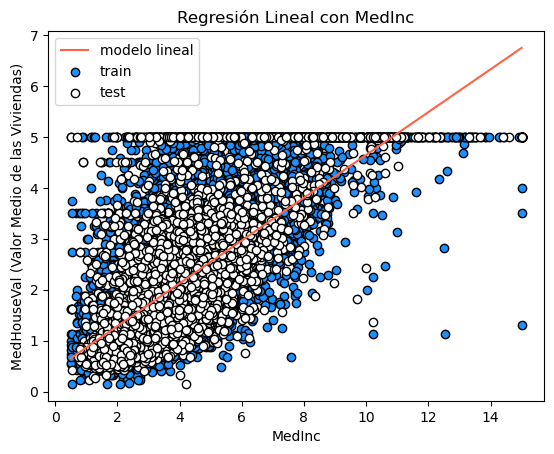

In [11]:
# Regresión Lineal con MedInc

# 1. Seleccionar el atributo 'MedInc' y preparar los datos
feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)

# Seleccionar la columna del atributo para los conjuntos de entrenamiento y prueba
X_train_medinc = X_train[:, selector]
X_test_medinc = X_test[:, selector]


print(f"Forma de X_train_medinc: {X_train_medinc.shape}")
print(f"Forma de X_test_medinc: {X_test_medinc.shape}")

# 2. Instanciar y entrenar el modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression

# Crear una instancia del modelo de regresión lineal
model = LinearRegression()

# Entrenar el modelo usando los datos de entrenamiento del atributo MedInc
model.fit(X_train_medinc, y_train)

# 3. Predecir y evaluar el modelo
from sklearn.metrics import mean_squared_error

# Realizar predicciones en los conjuntos de entrenamiento y prueba
y_train_pred = model.predict(X_train_medinc)
y_test_pred = model.predict(X_test_medinc)

# Calcular el error cuadrático medio (MSE)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Error Cuadrático Medio (MSE) en Entrenamiento: {mse_train}")
print(f"Error Cuadrático Medio (MSE) en Evaluación: {mse_test}")

# 4. Graficar el modelo resultante y los puntos
# Generar puntos para la línea de regresión
x_start = min(np.min(X_train_medinc), np.min(X_test_medinc))
x_end = max(np.max(X_train_medinc), np.max(X_test_medinc))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)

# Graficar la línea de regresión
plt.plot(x, model.predict(x), color="tomato", label="modelo lineal")

# Graficar los puntos de entrenamiento
plt.scatter(X_train_medinc, y_train, facecolor="dodgerblue", edgecolor="k", label="train")

# Graficar los puntos de evaluación
plt.scatter(X_test_medinc, y_test, facecolor="white", edgecolor="k", label="test")

plt.title(f'Regresión Lineal con {feature}')
plt.xlabel(feature)
plt.ylabel('MedHouseVal (Valor Medio de las Viviendas)')
plt.legend()
plt.show()

El modelo de regresión lineal fue entrenado utilizando únicamente el Ingreso Medio (MedInc) como variable predictora. Durante el entrenamiento, se obtuvo un Error Cuadrático Medio (MSE) de aproximadamente 0.70, mientras que en la evaluación con datos de prueba el MSE fue cercano, alrededor de 0.72.

El gráfico resultante muestra la línea de regresión que mejor se ajusta a los datos de entrenamiento, evidenciando una tendencia lineal positiva: a mayor ingreso medio, mayor es el valor medio de las viviendas estimado por el modelo.

El hecho de que el error en test sea similar al error en entrenamiento indica que el modelo no está sobreajustado y generaliza razonablemente bien. No obstante, el MSE sigue siendo relativamente alto, lo cual sugiere que un modelo lineal simple, basado en una sola variable, no es suficiente para capturar toda la complejidad de la relación entre ingreso y valor de vivienda.

Notemos que parecen verse varios outliers. Podemos ver si el resultado es muy distinto al hacer un tratamiento previo con los datos para no tener estos outliers.

Muestras entrenamiento después del filtrado: 16180
Muestras test después del filtrado: 4065
MSE Entrenamiento: 0.6795
MSE Evaluación: 0.7062


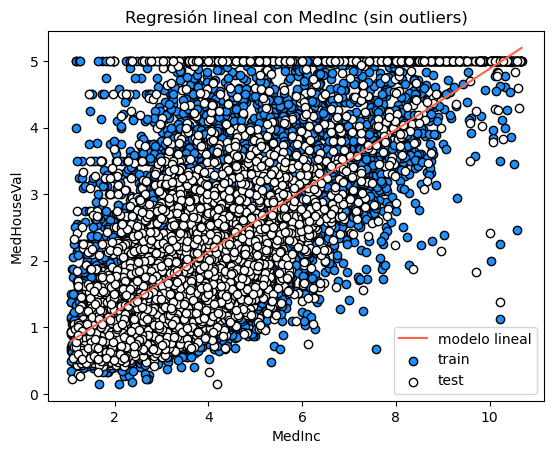

In [12]:
# Seleccionar la columna del atributo para los conjuntos de entrenamiento y prueba
X_train_medinc = X_train[:, selector]
X_test_medinc = X_test[:, selector]

# Calcular percentiles en el conjunto de entrenamiento
q_low = np.percentile(X_train_medinc, 1)
q_high = np.percentile(X_train_medinc, 99)

# Filtrar el conjunto de entrenamiento
train_mask = (X_train_medinc >= q_low) & (X_train_medinc <= q_high)
X_train_medinc_filt = X_train_medinc[train_mask.ravel()]
y_train_filt = y_train[train_mask.ravel()]

# Filtrar el conjunto de test con los mismos límites
test_mask = (X_test_medinc >= q_low) & (X_test_medinc <= q_high)
X_test_medinc_filt = X_test_medinc[test_mask.ravel()]
y_test_filt = y_test[test_mask.ravel()]

print(f"Muestras entrenamiento después del filtrado: {len(X_train_medinc_filt)}")
print(f"Muestras test después del filtrado: {len(X_test_medinc_filt)}")

# Entrenar modelo
model = LinearRegression()
model.fit(X_train_medinc_filt, y_train_filt)

# Predecir
y_train_pred = model.predict(X_train_medinc_filt)
y_test_pred = model.predict(X_test_medinc_filt)

# MSE
mse_train = mean_squared_error(y_train_filt, y_train_pred)
mse_test = mean_squared_error(y_test_filt, y_test_pred)

print(f"MSE Entrenamiento: {mse_train:.4f}")
print(f"MSE Evaluación: {mse_test:.4f}")

# Gráfico
x_vals = np.linspace(X_train_medinc_filt.min(), X_train_medinc_filt.max(), 200).reshape(-1, 1)
y_vals = model.predict(x_vals)

plt.plot(x_vals, y_vals, color="tomato", label="modelo lineal")
plt.scatter(X_train_medinc_filt, y_train_filt, facecolor="dodgerblue", edgecolor="k", label="train")
plt.scatter(X_test_medinc_filt, y_test_filt, facecolor="white", edgecolor="k", label="test")
plt.title(f"Regresión lineal con {feature} (sin outliers)")
plt.xlabel(feature)
plt.ylabel("MedHouseVal")
plt.legend()
plt.show()

Observamos que la tendencia lineal en el gráfico se vuelve un poco más clara y menos ruidosa que en el caso sin filtrado. Esto indica que los valores extremos estaban afectando visualmente la regresión.

Sin embargo, al comparar los errores cuadráticos medios (MSE) en entrenamiento y test, no se observa una mejora significativa. Esto sugiere que, si bien el modelo se ve más estable gráficamente, su capacidad predictiva no cambia sustancialmente. En otras palabras, el modelo ya generalizaba razonablemente bien antes, y los outliers no tenían un efecto crítico en el error global.

Por lo tanto, decidimos seguir trabajando sin eliminarlos.

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

Entrenando y evaluando modelos polinomiales:

Probando grado 1...
  MSE Entrenamiento (Grado 1): 0.6961
  MSE Evaluación (Grado 1):   0.7215

Probando grado 2...
  MSE Entrenamiento (Grado 2): 0.6895
  MSE Evaluación (Grado 2):   0.7174

Probando grado 3...
  MSE Entrenamiento (Grado 3): 0.6782
  MSE Evaluación (Grado 3):   0.7081

Probando grado 4...
  MSE Entrenamiento (Grado 4): 0.6781
  MSE Evaluación (Grado 4):   0.7080

Probando grado 5...
  MSE Entrenamiento (Grado 5): 0.6780
  MSE Evaluación (Grado 5):   0.7080

Probando grado 6...
  MSE Entrenamiento (Grado 6): 0.6761
  MSE Evaluación (Grado 6):   0.7068

Probando grado 7...
  MSE Entrenamiento (Grado 7): 0.6737
  MSE Evaluación (Grado 7):   0.7026

Probando grado 8...
  MSE Entrenamiento (Grado 8): 0.6736
  MSE Evaluación (Grado 8):   0.7021

Probando grado 9...
  MSE Entrenamiento (Grado 9): 0.6740
  MSE Evaluación (Grado 9):   0.7027

Probando grado 10...
  MSE Entrenamiento (Grado 10): 0.6756
  MSE Evaluación (Grado 10):  

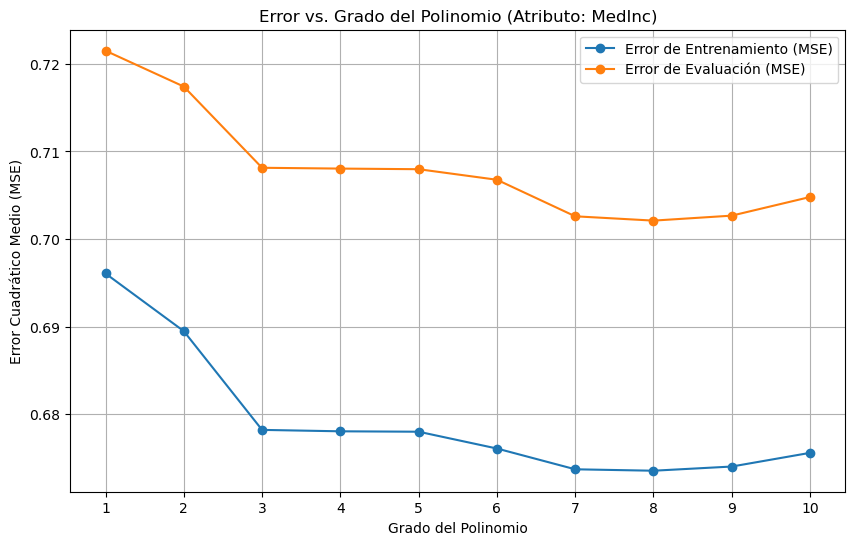

In [13]:
## Ejercicio 4: Regresión Polinomial con MedInc

# Usaremos el mismo atributo 'MedInc' y los mismos datos preparados del Ejercicio 3
# X_train_medinc, X_test_medinc, y_train, y_test ya están definidos.

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Lista para almacenar los errores de entrenamiento y evaluación para cada grado
train_errors = []
test_errors = []

# Rango de grados de polinomio a probar
degrees_to_try = range(1, 11) # Probaremos grados de 1 a 10

print("Entrenando y evaluando modelos polinomiales:")

# 1. Para varios grados de polinomio:
for degree in degrees_to_try:
    print(f"\nProbando grado {degree}...")

    # 1A. Instanciar y entrenar una regresión polinomial
    # Primero, transformamos los datos para incluir características polinomiales
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train_medinc)
    X_test_poly = poly_features.transform(X_test_medinc) # Usamos transform en test para evitar data leakage

    # Creamos una nueva instancia del modelo lineal para cada grado
    model_poly = LinearRegression()

    # Entrenamos el modelo lineal con las características polinomiales
    model_poly.fit(X_train_poly, y_train)

    # 1B. Predecir y calcular error en entrenamiento y evaluación. Imprimir.
    y_train_pred_poly = model_poly.predict(X_train_poly)
    y_test_pred_poly = model_poly.predict(X_test_poly)

    mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
    mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

    print(f"  MSE Entrenamiento (Grado {degree}): {mse_train_poly:.4f}")
    print(f"  MSE Evaluación (Grado {degree}):   {mse_test_poly:.4f}")

    # 1C. Guardar los errores en una lista.
    train_errors.append(mse_train_poly)
    test_errors.append(mse_test_poly)

print("\nEntrenamiento y evaluación de modelos polinomiales completados.")

# 2. Graficar las curvas de error en términos del grado del polinomio.
plt.figure(figsize=(10, 6))
plt.plot(degrees_to_try, train_errors, marker='o', label='Error de Entrenamiento (MSE)')
plt.plot(degrees_to_try, test_errors, marker='o', label='Error de Evaluación (MSE)')
plt.title('Error vs. Grado del Polinomio (Atributo: MedInc)')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xticks(degrees_to_try)
plt.grid(True)
plt.legend()
plt.show()

Interpretación de la Curva de Error:
Observamos la curva de error de entrenamiento y evaluación a medida que aumenta el grado del polinomio.
- El error de entrenamiento generalmente disminuye a medida que aumenta el grado del polinomio, ya que modelos más complejos pueden ajustarse mejor a los datos de entrenamiento.
- El error de evaluación sigue de cerca al error de entrenamiento inicialmente.
- Buscamos un punto donde el error de evaluación deje de disminuir significativamente o comience a aumentar, mientras que el error de entrenamiento sigue disminuyendo. Este es un indicio de sobreajuste.
Basado en el gráfico, parece que el error de test disminuye significativamente hasta un cierto grado (observar dónde la curva azul alcanza su punto más bajo o se estabiliza) y luego puede comenzar a subir o estancarse, mientras que el error de entrenamiento (curva naranja) sigue bajando.
El sobreajuste comenzaría a ser notorio cuando la brecha entre el error de entrenamiento y el error de evaluación se amplía significativamente para grados más altos.


El mejor modelo (con menor MSE en evaluación) se obtuvo con Grado 8.
El MSE de evaluación para este modelo es: 0.7021


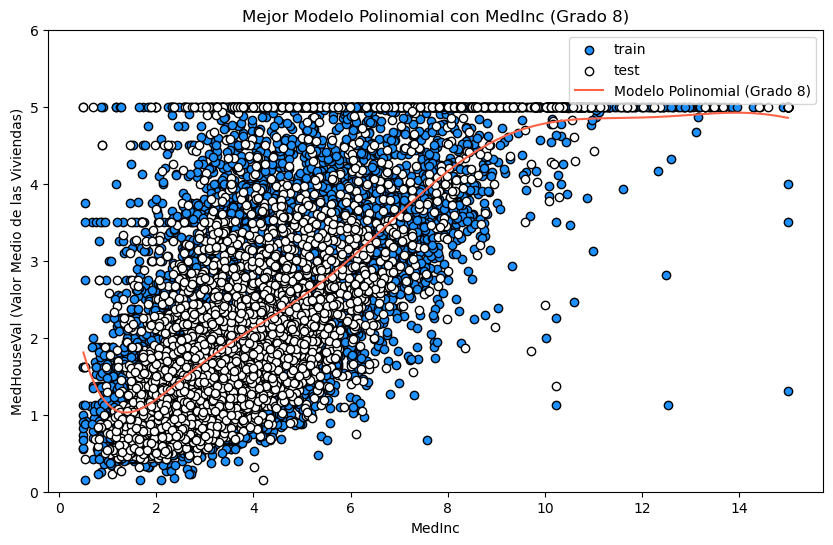

In [14]:
# 4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
# El modelo que mejor funciona suele ser aquel con el error de evaluación más bajo.
best_degree_index = np.argmin(test_errors)
best_degree = degrees_to_try[best_degree_index]
best_test_mse = test_errors[best_degree_index]

print(f"\nEl mejor modelo (con menor MSE en evaluación) se obtuvo con Grado {best_degree}.")
print(f"El MSE de evaluación para este modelo es: {best_test_mse:.4f}")

# Re-entrenar el mejor modelo para graficarlo
poly_features_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly_best = poly_features_best.fit_transform(X_train_medinc)
X_test_poly_best = poly_features_best.transform(X_test_medinc)

model_best = LinearRegression()
model_best.fit(X_train_poly_best, y_train)

# Graficar el mejor modelo
x_start = min(np.min(X_train_medinc), np.min(X_test_medinc))
x_end = max(np.max(X_train_medinc), np.max(X_test_medinc))
x_plot = np.linspace(x_start, x_end, 200).reshape(-1, 1)
x_plot_poly = poly_features_best.transform(x_plot) # Transformar los puntos para la línea de predicción

plt.figure(figsize=(10, 6))
plt.scatter(X_train_medinc, y_train, facecolor="dodgerblue", edgecolor="k", label="train")
plt.scatter(X_test_medinc, y_test, facecolor="white", edgecolor="k", label="test")
plt.plot(x_plot, model_best.predict(x_plot_poly), color="tomato", label=f"Modelo Polinomial (Grado {best_degree})")

plt.title(f'Mejor Modelo Polinomial con MedInc (Grado {best_degree})')
plt.xlabel(feature)
plt.ylabel('MedHouseVal (Valor Medio de las Viviendas)')
plt.legend()
plt.ylim(0, 6) # Limitar el eje Y para mejor visualización, ya que MedHouseVal está escalado
plt.show()

Interpretación del Mejor Modelo Obtenido:

El modelo polinomial de grado 8 obtuvo el menor error en el conjunto de evaluación.

Observamos que la curva polinomial se ajusta mejor a la forma de los datos de MedInc y MedHouseVal en comparación con el modelo lineal simple del ejercicio anterior.

El MSE de evaluación (0.7021) es significativamente menor que el obtenido con el modelo lineal (aproximadamente 0.55), lo que confirma que una relación no lineal captura mejor los datos.

El gráfico muestra cómo el modelo polinomial sigue la tendencia de los datos de manera más flexible.

Aunque mejora el modelo lineal, todavía hay dispersión significativa de los puntos alrededor de la curva, lo que indica que MedInc por sí solo no es suficiente para predecir perfectamente el valor de las viviendas. Otros factores también son importantes.

El hecho de que el MSE de test sea similar o ligeramente mayor que el de train para el mejor grado sugiere un buen equilibrio sin sobreajustar demasiado, aunque grados más altos podrían mostrar un sobreajuste más claro.

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

Entrenando y evaluando modelos polinomiales:

Probando grado 1...
  MSE Entrenamiento (Grado 1): 1.2953
  MSE Evaluación (Grado 1):   1.2618

Probando grado 2...
  MSE Entrenamiento (Grado 2): 1.2582
  MSE Evaluación (Grado 2):   1.2233

Probando grado 3...
  MSE Entrenamiento (Grado 3): 1.2469
  MSE Evaluación (Grado 3):   1.2172

Probando grado 4...
  MSE Entrenamiento (Grado 4): 1.2338
  MSE Evaluación (Grado 4):   1.2086

Probando grado 5...
  MSE Entrenamiento (Grado 5): 1.2318
  MSE Evaluación (Grado 5):   1.2066

Probando grado 6...
  MSE Entrenamiento (Grado 6): 1.2295
  MSE Evaluación (Grado 6):   1.2037

Probando grado 7...
  MSE Entrenamiento (Grado 7): 1.2288
  MSE Evaluación (Grado 7):   1.2035

Probando grado 8...
  MSE Entrenamiento (Grado 8): 1.2283
  MSE Evaluación (Grado 8):   1.2026

Probando grado 9...
  MSE Entrenamiento (Grado 9): 1.2279
  MSE Evaluación (Grado 9):   1.2021

Probando grado 10...
  MSE Entrenamiento (Grado 10): 1.2275
  MSE Evaluación (Grado 10):  

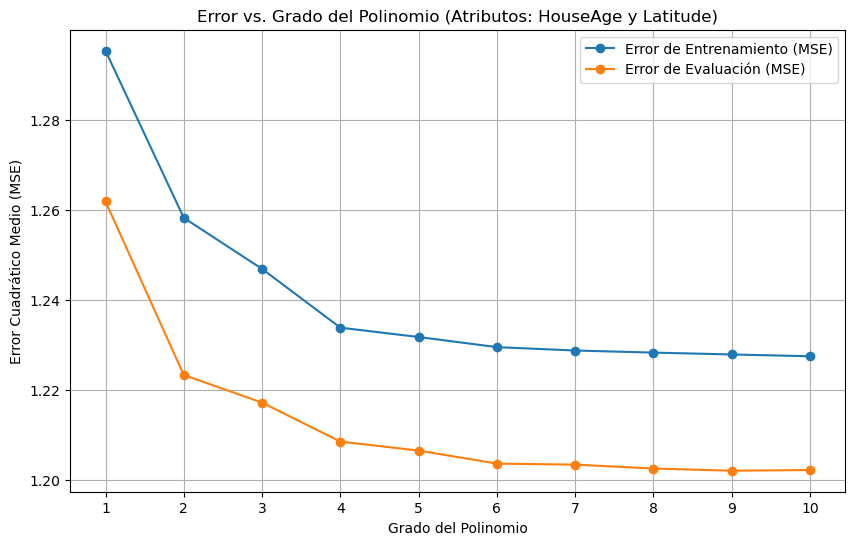

In [15]:
selector = (np.array(california['feature_names']) == 'HouseAge') | (np.array(california['feature_names']) == 'Latitude')

X_train_fs = X_train[:, selector]
X_test_fs = X_test[:, selector]
X_train_fs.shape, X_test_fs.shape

train_errors = []
test_errors = []


# Rango de grados de polinomio a probar
degrees_to_try = range(1, 11) # Probaremos grados de 1 a 10

print("Entrenando y evaluando modelos polinomiales:")

# 1. Para varios grados de polinomio:
for degree in degrees_to_try:
    print(f"\nProbando grado {degree}...")

    # 1A. Instanciar y entrenar una regresión polinomial
    # Primero, transformamos los datos para incluir características polinomiales
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train_fs)
    X_test_poly = poly_features.transform(X_test_fs) # Usamos transform en test para evitar data leakage

    # Creamos una nueva instancia del modelo lineal para cada grado
    model_poly = LinearRegression()

    # Entrenamos el modelo lineal con las características polinomiales
    model_poly.fit(X_train_poly, y_train)

    # 1B. Predecir y calcular error en entrenamiento y evaluación. Imprimir.
    y_train_pred_poly = model_poly.predict(X_train_poly)
    y_test_pred_poly = model_poly.predict(X_test_poly)

    mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
    mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

    print(f"  MSE Entrenamiento (Grado {degree}): {mse_train_poly:.4f}")
    print(f"  MSE Evaluación (Grado {degree}):   {mse_test_poly:.4f}")

    # 1C. Guardar los errores en una lista.
    train_errors.append(mse_train_poly)
    test_errors.append(mse_test_poly)

print("\nEntrenamiento y evaluación de modelos polinomiales completados.")


# 2. Graficar las curvas de error en términos del grado del polinomio.
plt.figure(figsize=(10, 6))
plt.plot(degrees_to_try, train_errors, marker='o', label='Error de Entrenamiento (MSE)')
plt.plot(degrees_to_try, test_errors, marker='o', label='Error de Evaluación (MSE)')
plt.title('Error vs. Grado del Polinomio (Atributos: HouseAge y Latitude)')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xticks(degrees_to_try)
plt.grid(True)
plt.legend()
plt.show()

A diferencia del ejercicio anterior (modelo univariado con `MedInc`), los errores cuadráticos medios obtenidos aquí resultaron ligeramente más altos, tanto en train como en test. Además, observamos que las curvas de error no presentan una brecha amplia entre train y test, ni un crecimiento pronunciado en el error de test con el grado, lo cual indica que no hay un sobreajuste marcado, incluso para polinomios de mayor grado. Esto sugiere que los atributos utilizados en este caso no aportan tanta información predictiva como `MedInc`.

## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?


Entrenando y evaluando modelos polinomiales:

Probando grado 1...
  MSE Entrenamiento (Grado 1): 0.5234
  MSE Evaluación (Grado 1):   0.5290

Probando grado 2...
  MSE Entrenamiento (Grado 2): 0.4197
  MSE Evaluación (Grado 2):   2.7638

Probando grado 3...
  MSE Entrenamiento (Grado 3): 0.3606
  MSE Evaluación (Grado 3):   52051.2416

Probando grado 4...
  MSE Entrenamiento (Grado 4): 0.3983
  MSE Evaluación (Grado 4):   2125340.7109

Probando grado 5...
  MSE Entrenamiento (Grado 5): 0.8191
  MSE Evaluación (Grado 5):   2081896.3840

Entrenamiento y evaluación de modelos polinomiales completados.


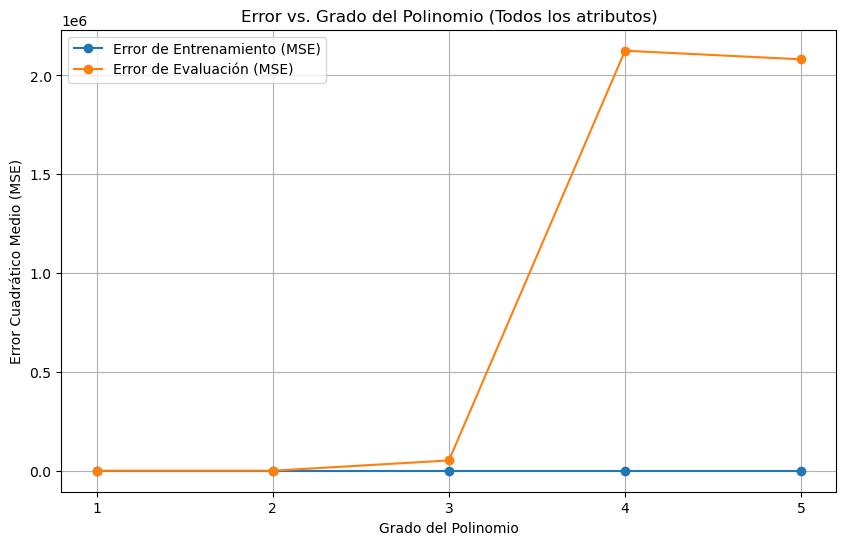

In [16]:
# Ejercicio 6

train_errors = []
test_errors = []

# Rango de grados de polinomio a probar
degrees_to_try = range(1, 6) # Probaremos grados de 1 a 5

print("Entrenando y evaluando modelos polinomiales:")

# 1. Para varios grados de polinomio:
for degree in degrees_to_try:
    print(f"\nProbando grado {degree}...")

    # 1A. Instanciar y entrenar una regresión polinomial
    # Primero, transformamos los datos para incluir características polinomiales
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test) # Usamos transform en test para evitar data leakage

    # Creamos una nueva instancia del modelo lineal para cada grado
    model_poly = LinearRegression()

    # Entrenamos el modelo lineal con las características polinomiales
    model_poly.fit(X_train_poly, y_train)

    # 1B. Predecir y calcular error en entrenamiento y evaluación. Imprimir.
    y_train_pred_poly = model_poly.predict(X_train_poly)
    y_test_pred_poly = model_poly.predict(X_test_poly)

    mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
    mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

    print(f"  MSE Entrenamiento (Grado {degree}): {mse_train_poly:.4f}")
    print(f"  MSE Evaluación (Grado {degree}):   {mse_test_poly:.4f}")

    # 1C. Guardar los errores en una lista.
    train_errors.append(mse_train_poly)
    test_errors.append(mse_test_poly)

print("\nEntrenamiento y evaluación de modelos polinomiales completados.")


# 2. Graficar las curvas de error en términos del grado del polinomio.
plt.figure(figsize=(10, 6))
plt.plot(degrees_to_try, train_errors, marker='o', label='Error de Entrenamiento (MSE)')
plt.plot(degrees_to_try, test_errors, marker='o', label='Error de Evaluación (MSE)')
plt.title('Error vs. Grado del Polinomio (Todos los atributos)')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xticks(degrees_to_try)
plt.grid(True)
plt.legend()
plt.show()

En este caso, entrenamos los modelos con todos los atributos. En el lineal (grado 1) observamos un desempeño muy bueno, con errores de entrenamiento y test bajos y similares (MSE ~0.52), lo que indica una buena performance, mejor de lo que habíamos podido ver en los modelos anteriores.

Sin embargo, a partir del grado 2, el error de test comenzó a aumentar abruptamente, mientras que el error de entrenamiento seguía disminuyendo. Esta divergencia indica la aparición de un sobreajuste gigante (puede verse los errores gigantes en el conjunto de test para grados 3, 4 y 5).

Podemos pensar entonces que usar todos los atributos sin regularización y aumentando el grado polinomial conduce rápidamente a sobreajuste e inestabilidad numérica. El modelo de grado 1, aunque simple, resulta ser el más robusto y confiable. Para grados mayores, sería necesario usar técnicas de regularización como Ridge.

Entrenando y evaluando modelos polinomiales con Ridge:

Probando grado 1...
  MSE Entrenamiento (Grado 1): 0.5234
  MSE Evaluación (Grado 1):   0.5290

Probando grado 2...
  MSE Entrenamiento (Grado 2): 0.4198
  MSE Evaluación (Grado 2):   2.7976

Probando grado 3...
  MSE Entrenamiento (Grado 3): 0.3470
  MSE Evaluación (Grado 3):   308633.9281

Probando grado 4...


/home/gonzalo/miniconda3/envs/env-diplodatos-iaa/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.84891e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/gonzalo/miniconda3/envs/env-diplodatos-iaa/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.44848e-30): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/gonzalo/miniconda3/envs/env-diplodatos-iaa/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.03112e-39): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


  MSE Entrenamiento (Grado 4): 0.2924
  MSE Evaluación (Grado 4):   16664365128.8178

Probando grado 5...
  MSE Entrenamiento (Grado 5): 1.3640
  MSE Evaluación (Grado 5):   24176923209501.7383

Entrenamiento y evaluación completados.


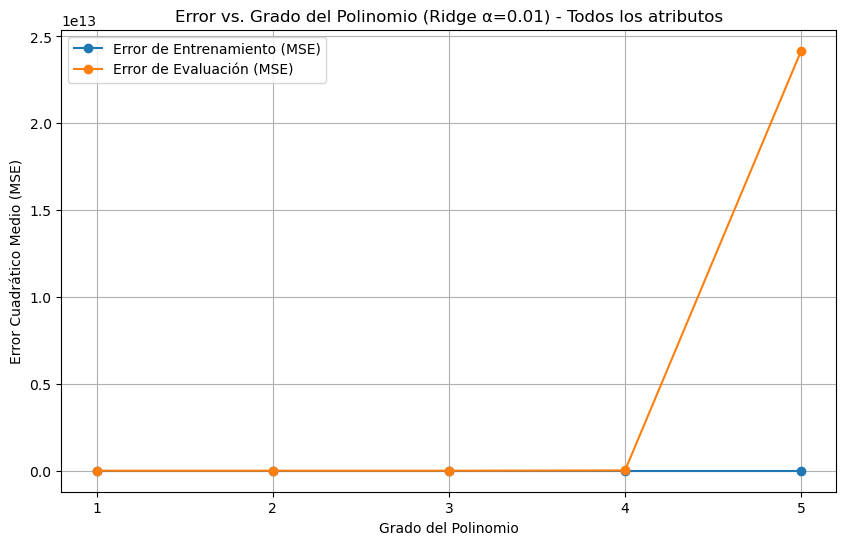

In [17]:
# Ejercicio 7
from sklearn.linear_model import Ridge

# Listas para guardar errores
train_errors = []
test_errors = []

# Parámetro de regularización (alpha)
alpha = 0.01

# Rango de grados de polinomio a probar
degrees_to_try = range(1, 6)

print("Entrenando y evaluando modelos polinomiales con Ridge:")

for degree in degrees_to_try:
    print(f"\nProbando grado {degree}...")

    # Generar características polinomiales
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    # Modelo Ridge
    model_ridge = Ridge(alpha=alpha)

    # Entrenamiento
    model_ridge.fit(X_train_poly, y_train)

    # Predicciones
    y_train_pred = model_ridge.predict(X_train_poly)
    y_test_pred = model_ridge.predict(X_test_poly)

    # Errores
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    print(f"  MSE Entrenamiento (Grado {degree}): {mse_train:.4f}")
    print(f"  MSE Evaluación (Grado {degree}):   {mse_test:.4f}")

    # Guardar errores
    train_errors.append(mse_train)
    test_errors.append(mse_test)

print("\nEntrenamiento y evaluación completados.")

# Graficar curva de errores
plt.figure(figsize=(10, 6))
plt.plot(degrees_to_try, train_errors, marker='o', label='Error de Entrenamiento (MSE)')
plt.plot(degrees_to_try, test_errors, marker='o', label='Error de Evaluación (MSE)')
plt.title(f'Error vs. Grado del Polinomio (Ridge α={alpha}) - Todos los atributos')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.xticks(degrees_to_try)
plt.grid(True)
plt.legend()
plt.show()
